In [1]:
import pduutil as pu
import pduhistoryserver as hs
import pandas as pd

datafiles_map = dict(pu.datafiles_iterator())

In [2]:
metric_names = hs.get_metric_names()
cpu_metrics = hs.get_cpu_metrics()
memory_metrics = hs.get_memory_metrics()
disk_read_metrics = hs.get_disk_read_metrics()
disk_write_metrics = hs.get_disk_write_metrics()
net_read_metrics = hs.get_net_read_metrics()

RAW_DF_FILE = "stages_with_metrics.csv.gz"
force_recalc = False
try:
    if force_recalc:
        print("Forcing recalculation")
        raise Exception
    print(f"Reading {RAW_DF_FILE}")
    raw_df = pd.read_csv(RAW_DF_FILE, compression="gzip")
except:
    print(f"Generating {RAW_DF_FILE}")
    from pdumetrics import PowerMetrics
    pm = PowerMetrics("all_power_processed.csv.gz")
    raw_df = hs.get_stages_dataframe(datafiles_map, metric_names, pm)
    raw_df.to_csv(RAW_DF_FILE, compression="gzip")
raw_df

Reading stages_with_metrics.csv.gz


,Unnamed: 0,app,app_id,app_start,app_end,num_machines,vm_config,app_runtime,app_energy,app_power_avg,...,energy,power_avg,internal.metrics.executorCpuTime,internal.metrics.executorDeserializeCpuTime,internal.metrics.peakExecutionMemory,internal.metrics.input.bytesRead,internal.metrics.shuffle.read.localBytesRead,internal.metrics.output.bytesWritten,internal.metrics.shuffle.write.bytesWritten,internal.metrics.shuffle.read.remoteBytesRead
0,0,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,1447.061534,290.000000,174351478,625224313,0,0,0,0,0,0
1,1,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,14678.124946,324.600000,236809871403,5145825322,0,17282373363,0,0,0,0
2,2,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,1572.779557,315.000000,12718394733,576376243,0,21240005760,0,0,0,0
3,3,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,3084.628677,299.333333,52941417073,488676466,0,42480011520,0,0,0,0
4,4,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,1475.676508,295.500000,28036068194,466096812,0,21960008640,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12689,12689,terasort,application_1716601033286_0018,2024-05-25 04:31:32.001000+00:00,2024-05-25 04:37:34.787000+00:00,6,vms6cores,362.786,213475.432823,576.693333,...,127667.842774,579.888889,1045897385790,2854568471,54873554160,0,2695778291,30000000000,0,13765807941
12690,12690,terasort,application_1716601033286_0019,2024-05-25 04:40:03.901000+00:00,2024-05-25 04:47:11.754000+00:00,6,vms6cores,427.853,247828.858083,569.272727,...,61007.661903,575.090909,612318579526,5009372317,52546240512,30000000000,0,0,16461586232,0
12691,12691,terasort,application_1716601033286_0019,2024-05-25 04:40:03.901000+00:00,2024-05-25 04:47:11.754000+00:00,6,vms6cores,427.853,247828.858083,569.272727,...,165596.854082,570.440678,945646839172,2646400810,54873554160,0,2981478610,30000000000,0,13480107622
12692,12692,terasort,application_1716601033286_0020,2024-05-25 04:49:34.196000+00:00,2024-05-25 04:55:07.362000+00:00,6,vms6cores,333.166,191203.750818,561.652174,...,63794.707467,554.000000,691836268073,5347912269,52546240512,30000000000,0,0,16461586232,0


In [3]:
df = raw_df

In [14]:
df.columns

Index(['Unnamed: 0', 'app', 'app_id', 'app_start', 'app_end', 'num_machines',
       'vm_config', 'app_runtime', 'app_energy', 'app_power_avg', 'stage_id',
       'stage_name', 'stage_submission_time', 'stage_completion_time',
       'stage_runtime', 'energy', 'power_avg',
       'internal.metrics.executorCpuTime',
       'internal.metrics.executorDeserializeCpuTime',
       'internal.metrics.peakExecutionMemory',
       'internal.metrics.input.bytesRead',
       'internal.metrics.shuffle.read.localBytesRead',
       'internal.metrics.output.bytesWritten',
       'internal.metrics.shuffle.write.bytesWritten',
       'internal.metrics.shuffle.read.remoteBytesRead', 'cpu', 'memory',
       'disk_read', 'disk_write', 'net_read'],
      dtype='object')

In [6]:
df[["app", "app_runtime"]]

,app,app_runtime
0,kmeans,299.146
1,kmeans,299.146
2,kmeans,299.146
3,kmeans,299.146
4,kmeans,299.146
...,...,...
12689,terasort,362.786
12690,terasort,427.853
12691,terasort,427.853
12692,terasort,333.166


In [16]:
df[ df["app"] == 'terasort' ][["app_id", "stage_id", "cpu", "energy"]]

,app_id,stage_id,cpu,energy
12376,application_1716833917453_0001,0,527782616854,18240.934198
12377,application_1716833917453_0001,1,1291991071844,123513.903669
12378,application_1716833917453_0002,0,719024038685,60851.813145
12379,application_1716833917453_0002,1,1288745479193,133175.848565
12380,application_1716833917453_0003,0,579651560835,60722.556675
...,...,...,...,...
12689,application_1716601033286_0018,1,1048751954261,127667.842774
12690,application_1716601033286_0019,0,617327951843,61007.661903
12691,application_1716601033286_0019,1,948293239982,165596.854082
12692,application_1716601033286_0020,0,697184180342,63794.707467


In [4]:
df["cpu"] = sum(df[m] for m in cpu_metrics)
df["memory"] = sum(df[m] for m in memory_metrics)
df["disk_read"] = sum(df[m] for m in disk_read_metrics)
df["disk_write"] = sum(df[m] for m in disk_write_metrics)
df["net_read"] = sum(df[m] for m in net_read_metrics)
df

,Unnamed: 0,app,app_id,app_start,app_end,num_machines,vm_config,app_runtime,app_energy,app_power_avg,...,internal.metrics.input.bytesRead,internal.metrics.shuffle.read.localBytesRead,internal.metrics.output.bytesWritten,internal.metrics.shuffle.write.bytesWritten,internal.metrics.shuffle.read.remoteBytesRead,cpu,memory,disk_read,disk_write,net_read
0,0,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,0,0,0,0,0,799575791,0,0,0,0
1,1,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,17282373363,0,0,0,0,241955696725,0,17282373363,0,0
2,2,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,21240005760,0,0,0,0,13294770976,0,21240005760,0,0
3,3,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,42480011520,0,0,0,0,53430093539,0,42480011520,0,0
4,4,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,21960008640,0,0,0,0,28502165006,0,21960008640,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12689,12689,terasort,application_1716601033286_0018,2024-05-25 04:31:32.001000+00:00,2024-05-25 04:37:34.787000+00:00,6,vms6cores,362.786,213475.432823,576.693333,...,0,2695778291,30000000000,0,13765807941,1048751954261,54873554160,2695778291,30000000000,13765807941
12690,12690,terasort,application_1716601033286_0019,2024-05-25 04:40:03.901000+00:00,2024-05-25 04:47:11.754000+00:00,6,vms6cores,427.853,247828.858083,569.272727,...,30000000000,0,0,16461586232,0,617327951843,52546240512,30000000000,16461586232,0
12691,12691,terasort,application_1716601033286_0019,2024-05-25 04:40:03.901000+00:00,2024-05-25 04:47:11.754000+00:00,6,vms6cores,427.853,247828.858083,569.272727,...,0,2981478610,30000000000,0,13480107622,948293239982,54873554160,2981478610,30000000000,13480107622
12692,12692,terasort,application_1716601033286_0020,2024-05-25 04:49:34.196000+00:00,2024-05-25 04:55:07.362000+00:00,6,vms6cores,333.166,191203.750818,561.652174,...,30000000000,0,0,16461586232,0,697184180342,52546240512,30000000000,16461586232,0


In [5]:
num_metrics = ["cpu", "memory", "disk_read", "disk_write", "net_read"]
df_num = df[num_metrics]
df_num

,cpu,memory,disk_read,disk_write,net_read
0,799575791,0,0,0,0
1,241955696725,0,17282373363,0,0
2,13294770976,0,21240005760,0,0
3,53430093539,0,42480011520,0,0
4,28502165006,0,21960008640,0,0
...,...,...,...,...,...
12689,1048751954261,54873554160,2695778291,30000000000,13765807941
12690,617327951843,52546240512,30000000000,16461586232,0
12691,948293239982,54873554160,2981478610,30000000000,13480107622
12692,697184180342,52546240512,30000000000,16461586232,0


In [6]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

est = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='kmeans', subsample=None)
est.fit(df_num.drop_duplicates())
num_metrics_scaled = [f"{column}_scaled" for column in num_metrics]
df_num_scaled = pd.DataFrame(est.transform(df_num), columns=num_metrics_scaled)
for column in df_num_scaled.columns:
    print(df_num_scaled[column].describe())
    df[column] = df_num_scaled[column]

df

count    12694.000000
mean         0.389790
std          0.819834
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: cpu_scaled, dtype: float64
count    12694.000000
mean         0.263747
std          0.683106
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: memory_scaled, dtype: float64
count    12694.000000
mean         0.600835
std          0.884686
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          4.000000
Name: disk_read_scaled, dtype: float64
count    12694.000000
mean         0.161572
std          0.641387
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: disk_write_scaled, dtype: float64
count    12694.000000
mean         0.066015
std          0.433080
min          0.000000
25%          0.000000
50%          0.000000
75%          0.0

/home/viniciusvdias/miniconda3/envs/python3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


,Unnamed: 0,app,app_id,app_start,app_end,num_machines,vm_config,app_runtime,app_energy,app_power_avg,...,cpu,memory,disk_read,disk_write,net_read,cpu_scaled,memory_scaled,disk_read_scaled,disk_write_scaled,net_read_scaled
0,0,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,799575791,0,0,0,0,0.0,0.0,0.0,0.0,0.0
1,1,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,241955696725,0,17282373363,0,0,1.0,0.0,2.0,0.0,0.0
2,2,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,13294770976,0,21240005760,0,0,0.0,0.0,2.0,0.0,0.0
3,3,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,53430093539,0,42480011520,0,0,0.0,0.0,4.0,0.0,0.0
4,4,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,28502165006,0,21960008640,0,0,0.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12689,12689,terasort,application_1716601033286_0018,2024-05-25 04:31:32.001000+00:00,2024-05-25 04:37:34.787000+00:00,6,vms6cores,362.786,213475.432823,576.693333,...,1048751954261,54873554160,2695778291,30000000000,13765807941,3.0,4.0,0.0,4.0,3.0
12690,12690,terasort,application_1716601033286_0019,2024-05-25 04:40:03.901000+00:00,2024-05-25 04:47:11.754000+00:00,6,vms6cores,427.853,247828.858083,569.272727,...,617327951843,52546240512,30000000000,16461586232,0,2.0,3.0,3.0,3.0,0.0
12691,12691,terasort,application_1716601033286_0019,2024-05-25 04:40:03.901000+00:00,2024-05-25 04:47:11.754000+00:00,6,vms6cores,427.853,247828.858083,569.272727,...,948293239982,54873554160,2981478610,30000000000,13480107622,3.0,4.0,0.0,4.0,3.0
12692,12692,terasort,application_1716601033286_0020,2024-05-25 04:49:34.196000+00:00,2024-05-25 04:55:07.362000+00:00,6,vms6cores,333.166,191203.750818,561.652174,...,697184180342,52546240512,30000000000,16461586232,0,2.0,3.0,3.0,3.0,0.0


In [7]:
df = df.sort_values(num_metrics_scaled)
df

,Unnamed: 0,app,app_id,app_start,app_end,num_machines,vm_config,app_runtime,app_energy,app_power_avg,...,cpu,memory,disk_read,disk_write,net_read,cpu_scaled,memory_scaled,disk_read_scaled,disk_write_scaled,net_read_scaled
0,0,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,799575791,0,0,0,0,0.0,0.0,0.0,0.0,0.0
8,8,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,2365031667,79016,149929,0,560277,0.0,0.0,0.0,0.0,0.0
10,10,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,1536486234,24000,307407,0,1506752,0.0,0.0,0.0,0.0,0.0
12,12,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,1113311337,24000,307401,0,1506778,0.0,0.0,0.0,0.0,0.0
14,14,kmeans,application_1716774568868_0001,2024-05-27 02:09:15.106000+00:00,2024-05-27 02:14:14.252000+00:00,3,vms3cores,299.146,87660.042757,286.870968,...,1412827297,0,0,0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12547,12547,terasort,application_1716648048801_0006,2024-05-25 17:02:51.240000+00:00,2024-05-25 17:21:10.836000+00:00,3,vms6cores,1099.596,294699.534574,267.832579,...,1232421830799,54873554160,5515221392,30000000000,10946364840,4.0,4.0,1.0,4.0,2.0
12549,12549,terasort,application_1716648048801_0007,2024-05-25 17:23:56.777000+00:00,2024-05-25 17:45:05.595000+00:00,3,vms6cores,1268.818,339802.730337,267.490196,...,1203128587989,54873554160,5487238167,30000000000,10974348065,4.0,4.0,1.0,4.0,2.0
12553,12553,terasort,application_1716648048801_0009,2024-05-25 18:08:51.816000+00:00,2024-05-25 18:28:28.073000+00:00,3,vms6cores,1176.257,316089.014301,267.822785,...,1179140612021,54873554160,5510230795,30000000000,10951355437,4.0,4.0,1.0,4.0,2.0
12565,12565,terasort,application_1716648048801_0015,2024-05-25 20:12:53.393000+00:00,2024-05-25 20:33:16.054000+00:00,3,vms6cores,1222.661,347121.681650,282.145749,...,1229828751033,54873554160,5480208130,30000000000,10981378102,4.0,4.0,1.0,4.0,2.0


In [8]:
gk = df.groupby(num_metrics_scaled)
groups = gk.groups

In [9]:
for i,v in enumerate(groups.keys()):
    v = tuple(v)
    g = gk.get_group(v)
    print(i, v, len(groups[v]), len(g[["app", "stage_name"]].drop_duplicates()), g["app"].unique())

0 (0.0, 0.0, 0.0, 0.0, 0.0) 4915 23 ['kmeans' 'matfact' 'pagerank' 'svm']
1 (0.0, 0.0, 0.0, 1.0, 0.0) 112 1 ['matfact']
2 (0.0, 0.0, 1.0, 0.0, 0.0) 2374 6 ['matfact' 'pagerank' 'svm']
3 (0.0, 0.0, 2.0, 0.0, 0.0) 392 4 ['kmeans']
4 (0.0, 0.0, 3.0, 0.0, 0.0) 90 2 ['kmeans']
5 (0.0, 0.0, 4.0, 0.0, 0.0) 160 1 ['kmeans']
6 (0.0, 1.0, 0.0, 0.0, 0.0) 1514 7 ['matfact']
7 (1.0, 0.0, 0.0, 0.0, 0.0) 450 3 ['matfact' 'pagerank']
8 (1.0, 0.0, 0.0, 0.0, 1.0) 2 1 ['svm']
9 (1.0, 0.0, 0.0, 0.0, 2.0) 100 1 ['svm']
10 (1.0, 0.0, 0.0, 0.0, 3.0) 40 1 ['svm']
11 (1.0, 0.0, 0.0, 1.0, 0.0) 37 1 ['matfact']
12 (1.0, 0.0, 1.0, 0.0, 0.0) 294 2 ['pagerank']
13 (1.0, 0.0, 1.0, 0.0, 1.0) 18 1 ['svm']
14 (1.0, 0.0, 1.0, 2.0, 0.0) 148 1 ['svm']
15 (1.0, 0.0, 2.0, 0.0, 0.0) 737 5 ['kmeans']
16 (1.0, 0.0, 3.0, 0.0, 0.0) 33 1 ['kmeans']
17 (1.0, 1.0, 0.0, 0.0, 0.0) 124 1 ['matfact']
18 (1.0, 2.0, 0.0, 0.0, 0.0) 4 1 ['matfact']
19 (1.0, 2.0, 0.0, 1.0, 0.0) 94 1 ['matfact']
20 (2.0, 0.0, 0.0, 0.0, 0.0) 17 1 ['pagerank']

In [10]:
df_selected = df[(df["app"] == "terasort") & (df["num_machines"] == 3) & (df["stage_id"] == 0)]
df_selected[num_metrics + ["energy", "power_avg"]].corr(numeric_only=True)[["energy"]]

,energy
cpu,0.722625
memory,NaN
disk_read,NaN
disk_write,NaN
net_read,NaN
energy,1.000000
power_avg,-0.485202


In [11]:
df_selected = df[(df["app"] == "terasort") & (df["num_machines"] == 4) & (df["stage_id"] == 0)]
df_selected[num_metrics + ["energy", "power_avg"]].corr(numeric_only=True)[["energy"]]

,energy
cpu,0.520296
memory,NaN
disk_read,NaN
disk_write,NaN
net_read,NaN
energy,1.000000
power_avg,-0.467315


In [12]:
df_selected = df[(df["app"] == "terasort") & (df["num_machines"] == 5) & (df["stage_id"] == 0)]
df_selected[num_metrics + ["energy", "power_avg"]].corr(numeric_only=True)[["energy"]]

,energy
cpu,0.813104
memory,NaN
disk_read,NaN
disk_write,NaN
net_read,NaN
energy,1.000000
power_avg,-0.536235


In [13]:
df_selected = df[(df["app"] == "terasort") & (df["num_machines"] == 6) & (df["stage_id"] == 0)]
df_selected[num_metrics + ["energy", "power_avg"]].corr(numeric_only=True)[["energy"]]

,energy
cpu,0.658129
memory,NaN
disk_read,NaN
disk_write,NaN
net_read,NaN
energy,1.000000
power_avg,-0.602987


In [14]:
pd.set_option('display.max_rows', 800)
df["energy_watth"] = df["energy"] / 3600
df.groupby(["app", "num_machines", "stage_name", "vm_config"])[["energy_watth"]].agg(["mean", "std"])

energy_watth  \
                                                                                           mean   
app      num_machines stage_name                                         vm_config                
kmeans   3            collect at KMeans.scala:381                        vms3cores     1.360594   
                                                                         vms6cores     1.958038   
                      collectAsMap at KMeans.scala:295                   vms3cores     0.457033   
                                                                         vms6cores     0.391589   
                      countByValue at KMeans.scala:399                   vms3cores     6.458736   
                                                                         vms6cores     2.814959   
                      mapPartitions at KMeans.scala:276                  vms3cores     5.686989   
                                                                         vms6cores     2.542120   
                      parquet at SparkFuncs.scala:124                    vms3cores     0.708701   
                                                                         vms6cores     0.677768   
                      show at SparkFuncs.scala:108                       vms3cores     0.513055   
                                                                         vms6cores     0.484296   
                      sum at KMeans.scala:373                            vms3cores     6.041023   
                                                                         vms6cores     3.788532   
                      sum at KMeansModel.scala:88                        vms3cores     5.252085   
                                                                         vms6cores     2.548639   
                      takeSample at KMeans.scala:353                     vms3cores     5.590271   
                                                                         vms6cores     5.468096   
         4            collect at KMeans.scala:381                        vms3cores     1.404195   
                                                                         vms6cores     3.020790   
                      collectAsMap at KMeans.scala:295                   vms3cores     0.566406   
                                                                         vms6cores     0.560259   
                      countByValue at KMeans.scala:399                   vms3cores     6.870023   
                                                                         vms6cores     3.163166   
                      mapPartitions at KMeans.scala:276                  vms3cores     6.251325   
                                                                         vms6cores     3.067638   
                      parquet at SparkFuncs.scala:124                    vms3cores     0.805183   
                                                                         vms6cores     0.843571   
                      show at SparkFuncs.scala:108                       vms3cores     0.638108   
                                                                         vms6cores     0.572126   
                      sum at KMeans.scala:373                            vms3cores     5.625360   
                                                                         vms6cores     6.768763   
                      sum at KMeansModel.scala:88                        vms3cores     5.789968   
                                                                         vms6cores     3.215983   
                      takeSample at KMeans.scala:353                     vms3cores     5.325064   
                                                                         vms6cores     4.890134   
         5            collect at KMeans.scala:381                        vms3cores     1.194549   
                                                                         vms6cores     0.949272   
                      co

## Nível estágios:
1. Parece existir um vencedor com relação ao tamanho de VM para cada aplicação
2. Quando a energia é contabilizada por estágio e por instanciação dentro da aplicação, o desvio do gasto de energia fica menor
3. Muitos estágios pequenos pode requerer um tratamento diferente para estimar consumo: talvez considerar janelas de estágios
4. Para a maioria das aplicações, o tamanho de VM é unânime, entretanto existem alguns poucos exemplos em que alguns estágios parecem consumir menos energia em tamanhos específicos de VM (por exemplo, Kmean, primeiro estágio). Infelizmente esse efeito é raro e inexpressivo em proporção de economia.
5. Terasort: VMs menores é uma configuração melhor. Hipótese: fetchWaitTime, por algum motivo parece que VM6 gera mais esperas bloqueadas.

In [15]:
pd.set_option('display.max_rows', 800)
df["energy_watth"] = df["energy"] / 3600
df.groupby(["app", "num_machines", "stage_id", "stage_name", "vm_config"])[["energy_watth"]].agg(["mean", "std"])

energy_watth  \
                                                                                                    mean   
app      num_machines stage_id stage_name                                         vm_config                
kmeans   3            0        parquet at SparkFuncs.scala:124                    vms3cores     0.708701   
                                                                                  vms6cores     0.677768   
                      1        takeSample at KMeans.scala:353                     vms3cores    10.137895   
                                                                                  vms6cores     8.692833   
                      2        takeSample at KMeans.scala:353                     vms3cores     1.042646   
                                                                                  vms6cores     2.243359   
                      3        sum at KMeans.scala:373                            vms3cores     2.791938   
                                                                                  vms6cores     2.916579   
                      4        collect at KMeans.scala:381                        vms3cores     1.306408   
                                                                                  vms6cores     2.589424   
                      5        sum at KMeans.scala:373                            vms3cores     9.290107   
                                                                                  vms6cores     4.660486   
                      6        collect at KMeans.scala:381                        vms3cores     1.414779   
                                                                                  vms6cores     1.326653   
                      7        countByValue at KMeans.scala:399                   vms3cores    12.372271   
                                                                                  vms6cores     5.126818   
                      8        countByValue at KMeans.scala:399                   vms3cores     0.545202   
                                                                                  vms6cores     0.503100   
                      9        mapPartitions at KMeans.scala:276                  vms3cores     5.379317   
                                                                                  vms6cores     2.407864   
                      10       collectAsMap at KMeans.scala:295                   vms3cores     0.468046   
                                                                                  vms6cores     0.393930   
                      11       mapPartitions at KMeans.scala:276                  vms3cores     5.994660   
                                                                                  vms6cores     2.676376   
                      12       collectAsMap at KMeans.scala:295                   vms3cores     0.446021   
                                                                                  vms6cores     0.389247   
                      13       sum at KMeansModel.scala:88                        vms3cores     5.252085   
                                                                                  vms6cores     2.548639   
                      14       show at SparkFuncs.scala:108                       vms3cores     0.513055   
                                                                                  vms6cores     0.484296   
         4            0        parquet at SparkFuncs.scala:124                    vms3cores     0.805183   
                                                                                  vms6cores     0.843571   
                      1        takeSample at KMeans.scala:353                     vms3cores     9.852983   
                                                                                  vms6cores     7.949907   
                      2        takeSample at KMeans.scala:353                     vms3cores     

In [16]:
pd.set_option('display.max_rows', 800)
df["energy_watth"] = df["energy"] / 3600
df["stage_performance_per_watt"] = (1 / df["stage_runtime"]) / df["power_avg"]
df.groupby(["app", "num_machines", "stage_id", "stage_name", "vm_config"])[["energy_watth", "power_avg", "stage_runtime", "stage_performance_per_watt"]].agg(["mean", "std"])

energy_watth  \
                                                                                                    mean   
app      num_machines stage_id stage_name                                         vm_config                
kmeans   3            0        parquet at SparkFuncs.scala:124                    vms3cores     0.708701   
                                                                                  vms6cores     0.677768   
                      1        takeSample at KMeans.scala:353                     vms3cores    10.137895   
                                                                                  vms6cores     8.692833   
                      2        takeSample at KMeans.scala:353                     vms3cores     1.042646   
                                                                                  vms6cores     2.243359   
                      3        sum at KMeans.scala:373                            vms3cores     2.791938   
                                                                                  vms6cores     2.916579   
                      4        collect at KMeans.scala:381                        vms3cores     1.306408   
                                                                                  vms6cores     2.589424   
                      5        sum at KMeans.scala:373                            vms3cores     9.290107   
                                                                                  vms6cores     4.660486   
                      6        collect at KMeans.scala:381                        vms3cores     1.414779   
                                                                                  vms6cores     1.326653   
                      7        countByValue at KMeans.scala:399                   vms3cores    12.372271   
                                                                                  vms6cores     5.126818   
                      8        countByValue at KMeans.scala:399                   vms3cores     0.545202   
                                                                                  vms6cores     0.503100   
                      9        mapPartitions at KMeans.scala:276                  vms3cores     5.379317   
                                                                                  vms6cores     2.407864   
                      10       collectAsMap at KMeans.scala:295                   vms3cores     0.468046   
                                                                                  vms6cores     0.393930   
                      11       mapPartitions at KMeans.scala:276                  vms3cores     5.994660   
                                                                                  vms6cores     2.676376   
                      12       collectAsMap at KMeans.scala:295                   vms3cores     0.446021   
                                                                                  vms6cores     0.389247   
                      13       sum at KMeansModel.scala:88                        vms3cores     5.252085   
                                                                                  vms6cores     2.548639   
                      14       show at SparkFuncs.scala:108                       vms3cores     0.513055   
                                                                                  vms6cores     0.484296   
         4            0        parquet at SparkFuncs.scala:124                    vms3cores     0.805183   
                                                                                  vms6cores     0.843571   
                      1        takeSample at KMeans.scala:353                     vms3cores     9.852983   
                                                                                  vms6cores     7.949907   
                      2        takeSample at KMeans.scala:353                     vms3cores     

## Nível aplicação por quantidade de máquinas

In [38]:
df["app_energy_watth"] = df["app_energy"] / 3600
df["stage_performance_per_watt"] = (1 / df["stage_runtime"]) / df["power_avg"]
df["app_performance_per_watt"] = (1 / df["app_runtime"]) / df["app_power_avg"]

### Sempre que tempo de execução ganha, consumo também é menor

In [56]:
runtime_best = df.groupby(["app", "num_machines", "vm_config"])["app_runtime"].agg(["mean"]).reset_index()
runtime_best_idx = runtime_best.groupby(["app", "num_machines"])["mean"].idxmin()
df_best_runtime = runtime_best.loc[runtime_best_idx][["app", "num_machines", "vm_config"]]

runtime_best = df.groupby(["app", "num_machines", "vm_config"])["app_energy_watth"].agg(["mean"]).reset_index()
runtime_best_idx = runtime_best.groupby(["app", "num_machines"])["mean"].idxmin()
df_best_energy = runtime_best.loc[runtime_best_idx][["app", "num_machines", "vm_config"]]

df_best = pd.DataFrame()
df_best["app"] = df_best_runtime["app"]
df_best["num_machines"] = df_best_runtime["num_machines"]
df_best["vm_config_runtime"] = df_best_runtime["vm_config"]
df_best["vm_config_energy"] = df_best_energy["vm_config"]
df_best

,app,num_machines,vm_config_runtime,vm_config_energy
1,kmeans,3,vms6cores,vms6cores
3,kmeans,4,vms6cores,vms6cores
5,kmeans,5,vms6cores,vms6cores
7,kmeans,6,vms6cores,vms6cores
9,matfact,3,vms6cores,vms6cores
11,matfact,4,vms6cores,vms6cores
13,matfact,5,vms6cores,vms6cores
15,matfact,6,vms6cores,vms6cores
17,pagerank,3,vms6cores,vms6cores
19,pagerank,4,vms6cores,vms6cores


### Comparando consumo, potência média e tempo de execução

In [17]:
pd.set_option('display.max_rows', 800)
grouped = df.groupby(["app", "num_machines", "vm_config"])[["app_energy_watth", "app_power_avg", "app_runtime", "app_performance_per_watt"]].agg(["mean"])
grouped.columns = [c for c,_ in grouped.columns]
grouped

app_energy_watth  app_power_avg  app_runtime  \
app      num_machines vm_config                                                 
kmeans   3            vms3cores         55.014718     276.579505   712.242750   
                      vms6cores         34.870612     285.866196   434.119700   
         4            vms3cores         56.006685     365.582108   547.327050   
                      vms6cores         44.046364     381.633069   410.824000   
         5            vms3cores         51.700246     477.523868   384.775900   
                      vms6cores         34.554357     465.617636   261.988900   
         6            vms3cores         73.386986     525.124534   499.840800   
                      vms6cores         62.199128     523.193018   424.845200   
matfact  3            vms3cores         73.093052     271.813630   965.156067   
                      vms6cores         40.232872     279.683002   513.192400   
         4            vms3cores         85.726934     369.842338   832.886176   
                      vms6cores         46.974043     378.912900   441.023150   
         5            vms3cores         56.716594     466.264772   432.857850   
                      vms6cores         46.204696     468.072584   351.376650   
         6            vms3cores        106.579759     535.753607   712.603294   
                      vms6cores         72.533255     537.188480   481.789550   
pagerank 3            vms3cores         33.777566     284.146672   422.551500   
                      vms6cores         20.897898     296.942374   249.264650   
         4            vms3cores         36.862404     381.443282   343.028900   
                      vms6cores         27.409503     383.601748   252.223250   
         5            vms3cores         32.404068     503.214881   227.262600   
                      vms6cores         27.103541     484.867270   196.876400   
         6            vms3cores         55.989607     535.691234   371.652450   
                      vms6cores         34.413213     549.808742   220.425950   
svm      3            vms3cores         44.498505     292.414734   543.096950   
                      vms6cores         33.125349     293.151223   401.107100   
         4            vms3cores         38.971065     391.470685   352.713350   
                      vms6cores         29.328912     399.180139   258.792700   
         5            vms3cores         43.505824     502.901231   305.909550   
                      vms6cores         32.037085     495.944438   227.205150   
         6            vms3cores         62.759630     546.027273   410.628750   
                      vms6cores         38.073666     574.351491   233.185000   
terasort 3            vms3cores         53.225954     282.869238   673.329950   
                      vms6cores         84.496190     270.926550  1118.498100   
         4            vms3cores         53.268327     374.575508   507.087700   
                      vms6cores         72.306949     370.267466   697.963105   
         5            vms3cores         53.358060     480.133859   394.540650   
                      vms6cores         70.937735     464.233402   545.979900   
         6            vms3cores         58.095727     542.693877   380.666300   
                      vms6cores         59.868242     551.687908   385.439900   

                                 app_performance_per_watt  
app      num_machines vm_config                            
kmeans   3            vms3cores                  0.000005  
                      vms6cores                  0.000008  
         4            vms3cores                  0.000005  
                      vms6cores                  0.000007  
         5            vms3cores                  0.000006  
                      vms6cores                  0.000008  
         6            vms3cores                  0.000004  
                      vms6cores                  0.000005  
matfact  3            vms3core

### Correlação entre as medidas de desempenho

In [18]:
grouped.corr()

,app_energy_watth,app_power_avg,app_runtime,app_performance_per_watt
app_energy_watth,1.000000,0.146058,0.762291,-0.911217
app_power_avg,0.146058,1.000000,-0.479803,-0.163072
app_runtime,0.762291,-0.479803,1.000000,-0.699917
app_performance_per_watt,-0.911217,-0.163072,-0.699917,1.000000


### Mais tempo, mais consumo;

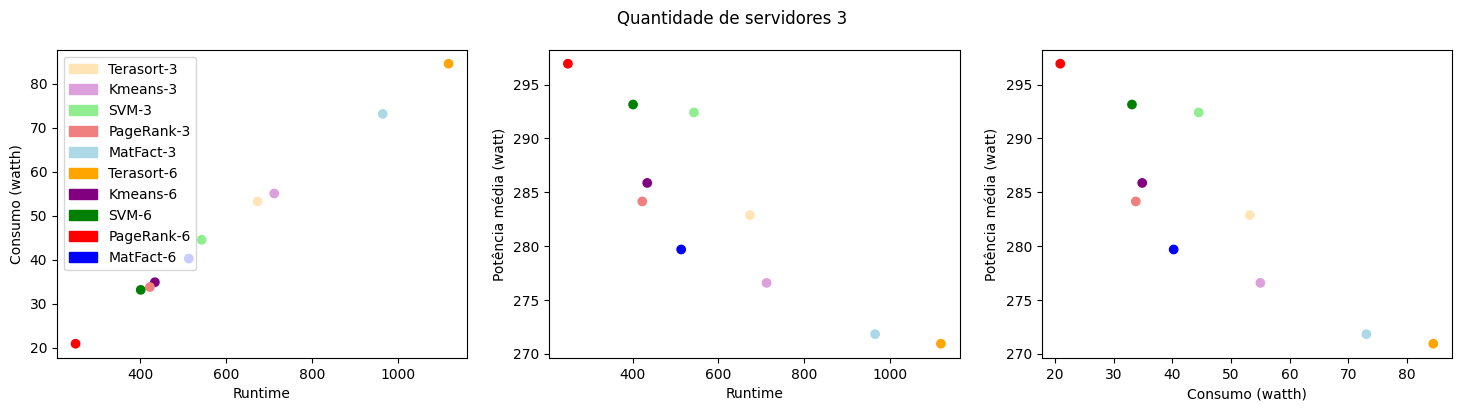

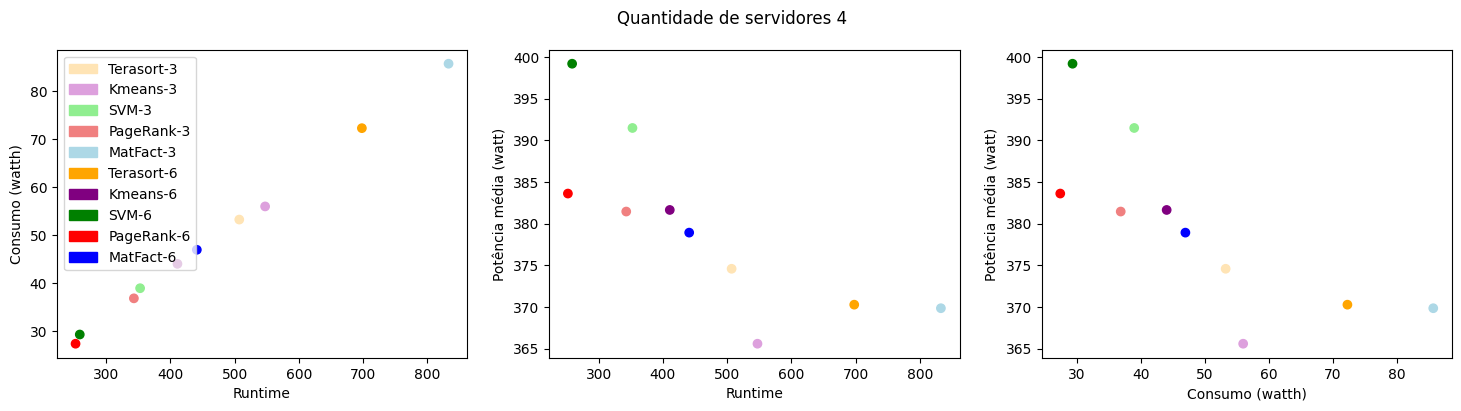

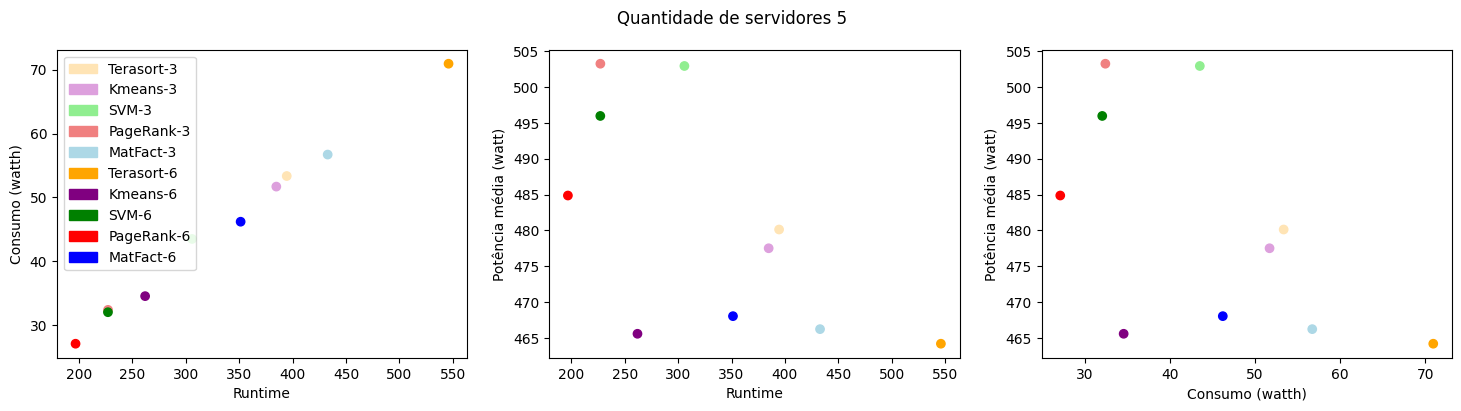

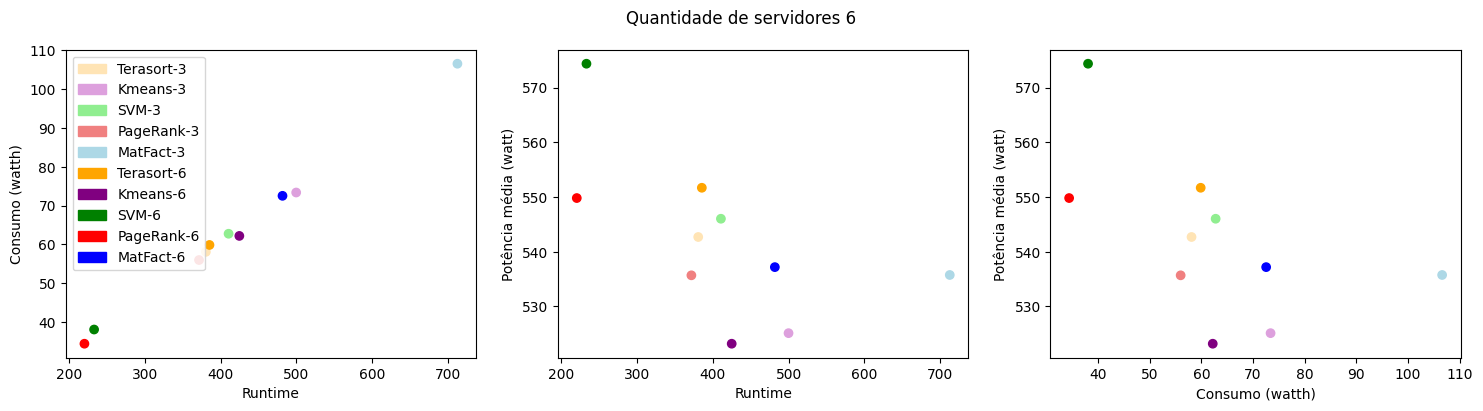

In [89]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

for num_machines in grouped.reset_index()["num_machines"].unique():
    grouped_by_app = grouped.reset_index()
    grouped_by_app = grouped_by_app[grouped_by_app["num_machines"] == num_machines]
    tuples = grouped_by_app[['app', 'vm_config']].itertuples(index=False)
    tuples = [tuple(t) for t in tuples]
    unique_tuples = grouped_by_app[['app', 'vm_config']].drop_duplicates().itertuples(index=False)
    unique_tuples = [tuple(t) for t in unique_tuples]
    colors = {('terasort','vms6cores'): 'orange', ('kmeans','vms6cores'): 'purple', ('svm','vms6cores'): 'green', ('matfact','vms6cores'): 'blue', ('pagerank','vms6cores'): 'red'}
    colors |= {('terasort','vms3cores'): 'moccasin', ('kmeans','vms3cores'): 'plum', ('svm','vms3cores'): 'lightgreen', ('matfact','vms3cores'): 'lightblue', ('pagerank','vms3cores'): 'lightcoral'}
    #color_list = [colors[group] for group in grouped_by_app['app']]
    color_list = [colors[group] for group in tuples]
    legend_handles = [
        mpatches.Patch(color=colors[('terasort','vms3cores')], label='Terasort-3'),
        mpatches.Patch(color=colors[('kmeans','vms3cores')], label='Kmeans-3'), 
        mpatches.Patch(color=colors[('svm','vms3cores')], label='SVM-3'), 
        mpatches.Patch(color=colors[('pagerank','vms3cores')], label='PageRank-3'), 
        mpatches.Patch(color=colors[('matfact','vms3cores')], label='MatFact-3'), 
        mpatches.Patch(color=colors[('terasort','vms6cores')], label='Terasort-6'),
        mpatches.Patch(color=colors[('kmeans','vms6cores')], label='Kmeans-6'), 
        mpatches.Patch(color=colors[('svm','vms6cores')], label='SVM-6'), 
        mpatches.Patch(color=colors[('pagerank','vms6cores')], label='PageRank-6'), 
        mpatches.Patch(color=colors[('matfact','vms6cores')], label='MatFact-6'), 
    ]
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,4))
    fig.suptitle(f"Quantidade de servidores {num_machines}")
    axs[0].scatter(x=grouped_by_app["app_runtime"], y=grouped_by_app["app_energy_watth"], c=color_list)
    axs[0].set_xlabel("Runtime")
    axs[0].set_ylabel("Consumo (watth)")
    axs[0].legend(handles=legend_handles, loc='upper left')
    
    axs[1].scatter(x=grouped_by_app["app_runtime"], y=grouped_by_app["app_power_avg"], c=color_list)
    axs[1].set_xlabel("Runtime")
    axs[1].set_ylabel("Potência média (watt)")
    #axs[1].legend(handles=legend_handles, loc='upper right')
    
    axs[2].scatter(x=grouped_by_app["app_energy_watth"], y=grouped_by_app["app_power_avg"], c=color_list)
    axs[2].set_xlabel("Consumo (watth)")
    axs[2].set_ylabel("Potência média (watt)")
    #axs[2].legend(handles=legend_handles, loc='upper right');